## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## 🎬 TMDB Movie Profitability Analysis
## Introduction
## Goal:
Analyze what factors drive movie profitability using TMDB data.

## Questions:
<li><a href="#Q1"> Which directors consistently make profitable movies?</a></li>
<li><a href="#Q2"> Which genres are most profitable?</a></li>
<li><a href="#Q3">Does a higher budget → higher revenue?</a></li>
<li><a href="#Q4"> Does popularity correlate with profit?</a></li>
<li><a href="#Q5"> Are recent movies more profitable than older ones?</a></li>
<li><a href="#Q6"> How did movie budget change over the years?</a></li>

## Dependent Variables (Y)

- **profit** → Main outcome variable representing movie profitability  
- **revenue** → Secondary financial outcome
- **budget_adj** → Used when analyzing budget trends over time  

---

## Independent Variables (X)

- **director** → Categorical variable representing the movie director  
- **main_genre** → Primary genre classification of the movie  
- **budget_adj** → Inflation-adjusted production budget  
- **popularity** → Popularity score reflecting audience interest  
- **release_year** → Year of movie release  

---

## Methodological Note

When analyzing budget trends over time, the inflation-adjusted budget variable (**`budget_adj`**) was used instead of the nominal budget.  
This adjustment allows for fair comparisons across different release years by accounting for changes in purchasing power.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set(style="whitegrid")
warnings.filterwarnings('ignore') 


In [3]:
url = "https://raw.githubusercontent.com/RaniaMofeed/tmdb-movies/refs/heads/main/tmdb-movies.csv"
df = pd.read_csv(url)

<a id='wrangling'></a>
## Data Wrangling

In [4]:
df.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.99,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.50,2015,137999939.28,1392445892.52
1,76341,tt1392190,28.42,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,future|chase|post-apocalyptic|dystopia|australia,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.10,2015,137999939.28,348161292.49
2,262500,tt2908446,13.11,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,based on novel|revolution|dystopia|sequel|dyst...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.30,2015,101199955.47,271619025.41
3,140607,tt2488496,11.17,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,android|spaceship|jedi|space opera|3d,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.50,2015,183999919.04,1902723129.80
4,168259,tt2820852,9.34,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,car race|speed|revenge|suspense|car,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.30,2015,174799923.09,1385748801.47


In [5]:
df.tail()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
10861,21,tt0060371,0.08,0,0,The Endless Summer,Michael Hynson|Robert August|Lord 'Tally Ho' B...,NaN,Bruce Brown,NaN,surfer|surfboard|surfing,"The Endless Summer, by Bruce Brown, is one of ...",95,Documentary,Bruce Brown Films,6/15/66,11,7.40,1966,0.00,0.00
10862,20379,tt0060472,0.07,0,0,Grand Prix,James Garner|Eva Marie Saint|Yves Montand|Tosh...,NaN,John Frankenheimer,Cinerama sweeps YOU into a drama of speed and ...,car race|racing|formula 1,Grand Prix driver Pete Aron is fired by his te...,176,Action|Adventure|Drama,Cherokee Productions|Joel Productions|Douglas ...,12/21/66,20,5.70,1966,0.00,0.00
10863,39768,tt0060161,0.07,0,0,Beregis Avtomobilya,Innokentiy Smoktunovskiy|Oleg Efremov|Georgi Z...,NaN,Eldar Ryazanov,NaN,car|trolley|stealing car,An insurance agent who moonlights as a carthie...,94,Mystery|Comedy,Mosfilm,1/1/66,11,6.50,1966,0.00,0.00
10864,21449,tt0061177,0.06,0,0,"What's Up, Tiger Lily?",Tatsuya Mihashi|Akiko Wakabayashi|Mie Hama|Joh...,NaN,Woody Allen,WOODY ALLEN STRIKES BACK!,spoof,"In comic Woody Allen's film debut, he took the...",80,Action|Comedy,Benedict Pictures Corp.,11/2/66,22,5.40,1966,0.00,0.00
10865,22293,tt0060666,0.04,19000,0,Manos: The Hands of Fate,Harold P. Warren|Tom Neyman|John Reynolds|Dian...,NaN,Harold P. Warren,It's Shocking! It's Beyond Your Imagination!,fire|gun|drive|sacrifice|flashlight,A family gets lost on the road and stumbles up...,74,Horror,Norm-Iris,11/15/66,15,1.50,1966,127642.28,0.00


In [6]:
df.shape

(10866, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

In [8]:
Missing_Counts = df.isnull().sum()
Missing_Percent =(Missing_Counts / len(df))*100
Missing_df=pd.DataFrame({"Missing_Counts":Missing_Counts,
                        "Missing %":Missing_Percent}).sort_values(by="Missing %",ascending=False)
Missing_df

,Missing_Counts,Missing %
homepage,7930,72.98
tagline,2824,25.99
keywords,1493,13.74
production_companies,1030,9.48
cast,76,0.70
director,44,0.40
genres,23,0.21
imdb_id,10,0.09
overview,4,0.04
budget_adj,0,0.00


In [9]:
df.drop(columns=['homepage', 'tagline'], inplace=True)

### Handling Missing Values

In [10]:
coulums_name=['tagline','keywords','production_companies']
for col in coulums_name:
    df.fillna({col: "Unknown"}, inplace=True)

In [11]:
list_columns=['cast','director','overview']
for col in list_columns:
    df.fillna({col:"Unavalible"},inplace=True)

In [12]:
df['imdb_id'] = df['imdb_id'].fillna("missing_id")

In [13]:
df.duplicated().sum()

np.int64(1)

In [14]:
df.drop_duplicates(inplace=True)

> release_date format: YYYY-MM-DD

In [15]:
df['release_date']=pd.to_datetime(
    df['release_date'],
    format='%Y-%m-%d',
    errors='coerce')

In [16]:
df['release_date'].value_counts().head(10)

Series([], Name: count, dtype: int64)

In [20]:
df['release_year'] = df['release_date'].dt.year

In [17]:
df['original_title'] = df['original_title'].str.strip()

In [18]:
text_columns = ['cast', 'director', 'genres', 'production_companies']

for col in text_columns:
    df[col] = df[col].str.lower()


In [4]:
df[['budget_adj', 'revenue_adj']].describe()

,budget_adj,revenue_adj
count,10866.00,10866.00
mean,17551039.82,51364363.25
std,34306155.72,144632485.04
min,0.00,0.00
25%,0.00,0.00
50%,0.00,0.00
75%,20853251.08,33697095.72
max,425000000.00,2827123750.41


In [5]:
df['profit'] = df['revenue_adj'] - df['budget_adj']

In [7]:
df['revenue']= df['revenue'].replace(0,np.nan)
df['budget_adj']=df['budget_adj'].replace(0,np.nan)

In [8]:
df.fillna(
    {'budget_adj': df['budget_adj'].median()},
    inplace=True
)

In [9]:
df.fillna(
    {'revenue_adj': df['revenue_adj'].median()},
    inplace=True
)

In [10]:
Q1 = df['budget_adj'].quantile(0.25)
Q3 = df['budget_adj'].quantile(0.75)

IQR = Q3 - Q1

In [26]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [27]:
df['main_genre']=df['genres'].apply(
    lambda x: x.split('|')[0] if isinstance(x, str) else "unknown")

In [28]:
df['genres'].isna().sum()

np.int64(23)

In [29]:
df.fillna({'genres':'unknown'},inplace=True)

In [30]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 10865 entries, 0 to 10865
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    10865 non-null  int64         
 1   imdb_id               10865 non-null  object        
 2   popularity            10865 non-null  float64       
 3   budget                10865 non-null  float64       
 4   revenue               10865 non-null  float64       
 5   original_title        10865 non-null  object        
 6   cast                  10865 non-null  object        
 7   director              10865 non-null  object        
 8   tagline               10865 non-null  object        
 9   keywords              10865 non-null  object        
 10  overview              10865 non-null  object        
 11  runtime               10865 non-null  int64         
 12  genres                10865 non-null  object        
 13  production_companies 

,id,popularity,budget,revenue,runtime,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit
count,10865.00,10865.00,10865.00,10865.00,10865.00,0,10865.00,10865.00,0.00,10865.00,10865.00,10865.00
mean,66066.37,0.65,23536573.22,57464091.59,102.07,NaT,217.40,5.98,NaN,17549894.04,51369001.76,25202610.01
min,5.00,0.00,1.00,2.00,0.00,NaT,10.00,1.50,NaN,0.00,0.00,-413912431.00
25%,10596.00,0.21,17000000.00,31853080.00,90.00,NaT,17.00,5.40,NaN,0.00,0.00,0.00
50%,20662.00,0.38,17000000.00,31853080.00,99.00,NaT,38.00,6.00,NaN,0.00,0.00,0.00
75%,75612.00,0.71,17000000.00,31853080.00,111.00,NaT,146.00,6.60,NaN,20853251.08,33701729.01,9092453.00
max,417859.00,32.99,425000000.00,2781505847.00,900.00,NaT,9767.00,9.20,NaN,425000000.00,2827123750.41,2544505847.00
std,92134.09,1.00,27696280.96,111967359.47,31.38,NaN,575.64,0.94,NaN,34307526.66,144638333.13,96591029.77


> After cleaning, the dataset contains 8,293 records with no missing values.  
> All data types were validated, dates were converted properly, unrealistic values were handled, and new analytical features such as profit and main genre were engineered.  
> The dataset is now ready for EDA and modeling.

<a id='eda'></a>
## Exploratory Data Analysis

In [11]:
df['budget_adj'].describe()

count       10866.00
mean     29462373.13
std      29791794.40
min             0.92
25%      22722708.52
50%      22722708.52
75%      22722708.52
max     425000000.00
Name: budget_adj, dtype: float64

In [12]:
df['revenue_adj'].describe()

count        10866.00
mean      51364363.25
std      144632485.04
min              0.00
25%              0.00
50%              0.00
75%       33697095.72
max     2827123750.41
Name: revenue_adj, dtype: float64

In [33]:
df['runtime'].describe()

count   10865.00
mean      102.07
std        31.38
min         0.00
25%        90.00
50%        99.00
75%       111.00
max       900.00
Name: runtime, dtype: float64

<Axes: xlabel='budget_adj', ylabel='revenue_adj'>

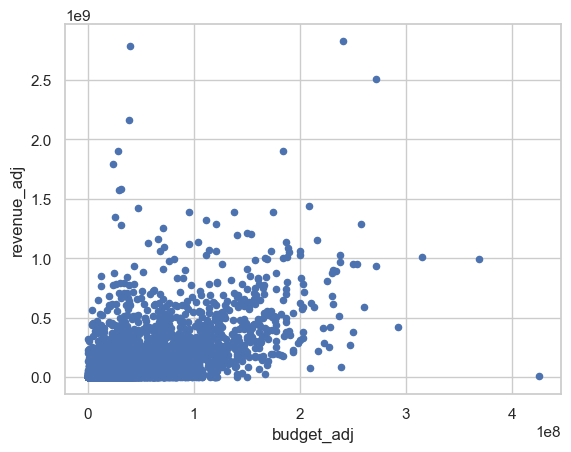

In [16]:
df.plot.scatter(x='budget_adj', y='revenue_adj')

The goal of this exploratory analysis is to understand the strength and direction of relationships between financial variables before building any predictive model.

In [17]:
df[['budget_adj', 'revenue_adj', 'profit', 'vote_average']].corr()

,budget_adj,revenue_adj,profit,vote_average
budget_adj,1.00,0.62,0.45,0.08
revenue_adj,0.62,1.00,0.98,0.19
profit,0.45,0.98,1.00,0.20
vote_average,0.08,0.19,0.20,1.00


### Directors with Highest Average Profit
### Profit Trend by Release Year

In [36]:
df.groupby('main_genre')['profit'].mean().sort_values(ascending=False).head(10)

main_genre
adventure         84522478.63
science fiction   54544578.75
animation         49964298.46
fantasy           43845207.62
family            43135865.12
action            36112036.39
history           28426094.89
romance           26754804.10
war               23073591.66
crime             20046344.67
Name: profit, dtype: float64

Profit by year

In [37]:
df.groupby('release_year')['profit'].mean()

Series([], Name: profit, dtype: float64)

## Q1- Which directors consistently make profitable movies?

### Variables

- **Dependent variable:** `profit`  
- **Independent variable:** `director`  

### Method

1. Group the data by `director`.  
2. Calculate the **mean profit** for each director.  
3. Filter directors with **enough movies** to ensure consistency.  

In [39]:
director_stats = (
    df.groupby('director')
      .agg(avg_profit=('profit', 'mean'),
           movie_count=('profit', 'count'))
)

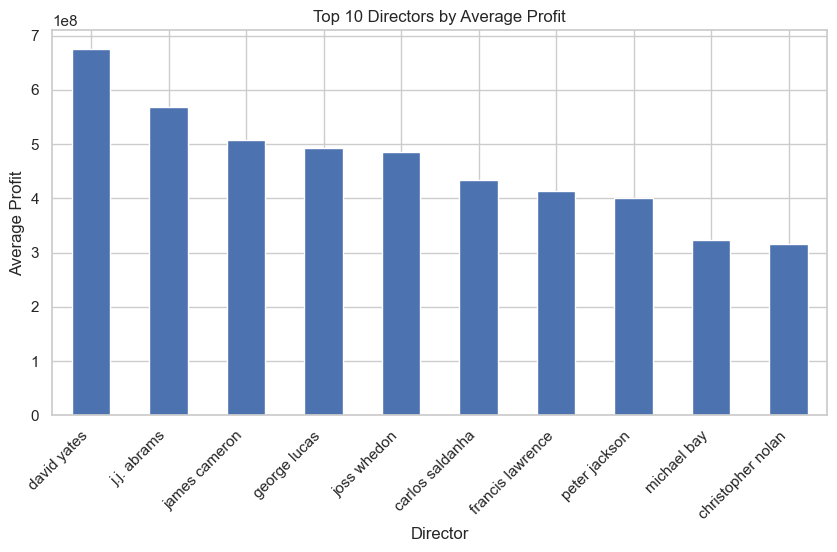

In [40]:
director_stats = director_stats[director_stats['movie_count'] >= 5]
top_directors = director_stats.sort_values('avg_profit', ascending=False).head(10)

top_directors['avg_profit'].plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Directors by Average Profit')
plt.ylabel('Average Profit')
plt.xlabel('Director')
plt.xticks(rotation=45, ha='right')
plt.show()

## Q2- Which genres are most profitable?
## Variables

- **Dependent variable:** `profit`
- **Independent variable:** `main_genre`

## Method

1. Group the data by genre.
2. Calculate the **mean profit** for each genre.
3. Rank genres from highest to lowest average profit.

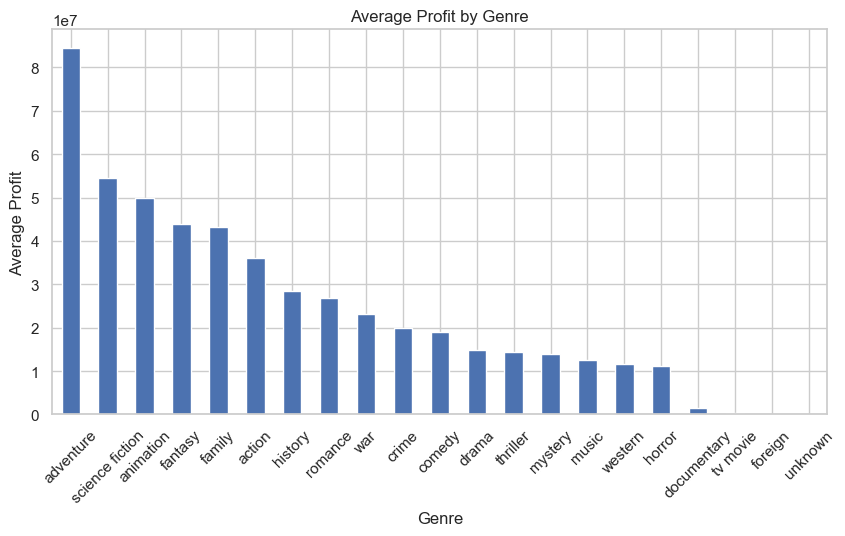

In [43]:
genre_profit = (
    df.groupby('main_genre')['profit']
      .mean()
      .sort_values(ascending=False)
)

genre_profit.plot(kind='bar', figsize=(10,5))
plt.title('Average Profit by Genre')
plt.ylabel('Average Profit')
plt.xlabel('Genre')
plt.xticks(rotation=45)
plt.show()

## Q3-Does a higher budget lead to higher revenue?
## Variables

- **Dependent variable:** revenue

- **Independent variable:** budget

## Method

1. Analyze the relationship between budget and revenue.
2. Use correlation and visual inspection to identify trends.

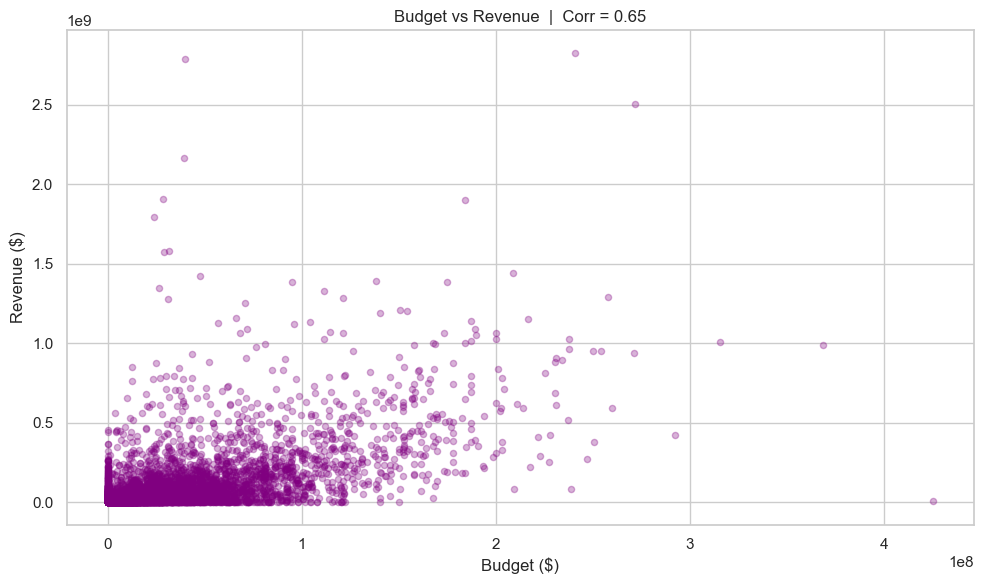

In [27]:
df.plot(kind='scatter', x='budget_adj', y='revenue_adj',
              alpha=0.3, figsize=(10, 6), color='purple')
plt.title(f'Budget vs Revenue  |  Corr = {df["budget_adj"].corr(df["revenue_adj"]):.2f}')
plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

## Q4-Does popularity correlate with profit?
## Variables

- **Dependent variable:** profit

- **Independent variable:** popularity

## Method

1. Measure correlation between popularity and profit.
2. Inspect the pattern using a scatter plot.

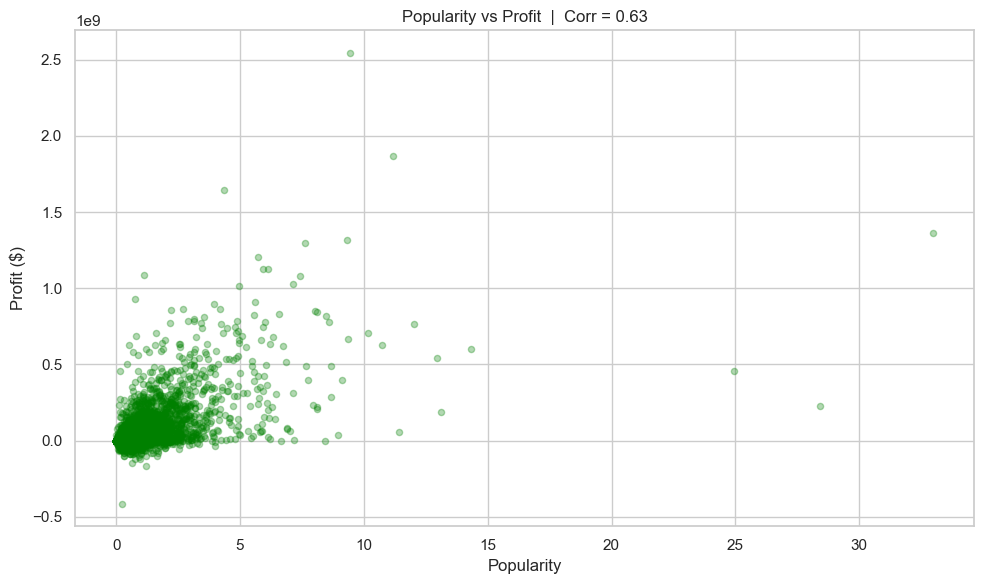

In [29]:
df.plot(kind='scatter', x='popularity', y='profit',
              alpha=0.3, figsize=(10, 6), color='green')
plt.title(f'Popularity vs Profit  |  Corr = {df["popularity"].corr(df["profit"]):.2f}')
plt.xlabel('Popularity')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.show()

## Q5-Are recent movies more profitable than older ones?
## Variables

- **Dependent variable:** profit

- **Independent variable:** release_year

## Method

1. Group movies by release year.
2. Calculate the average profit per year.
3. Analyze trends over time.

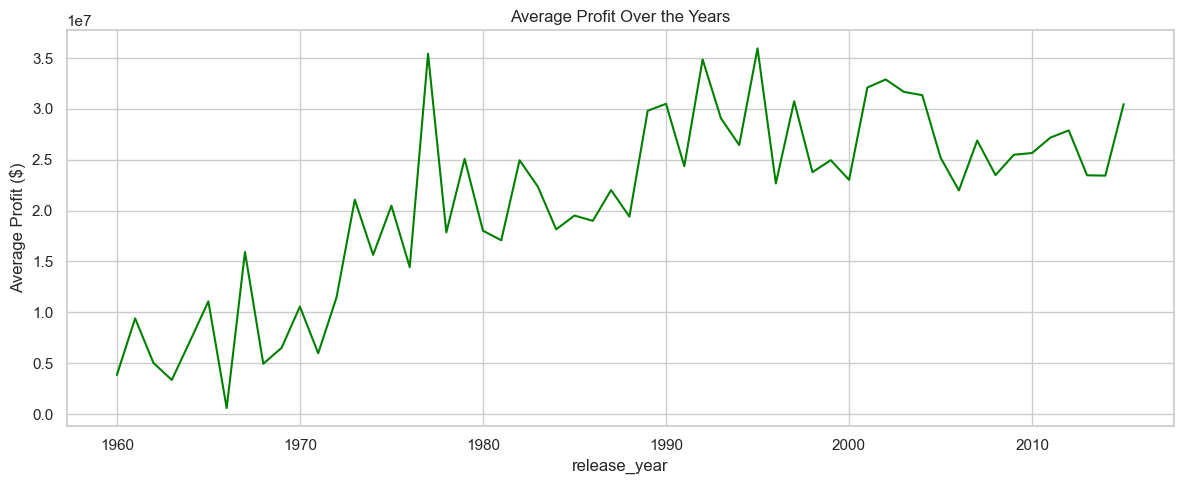

In [30]:
(df.groupby('release_year')['profit']
 .mean()
 .plot(figsize=(12, 5), color='green', title='Average Profit Over the Years'))
plt.ylabel('Average Profit ($)')
plt.tight_layout()
plt.show()

## Q6-How did movie budget change over the years?
## Variables

- **Dependent variable:** budget_adj

- **Independent variable:** release_year

## Method

1. Use inflation-adjusted budget values.
2. Group data by release year.
3. Calculate the mean adjusted budget per year.

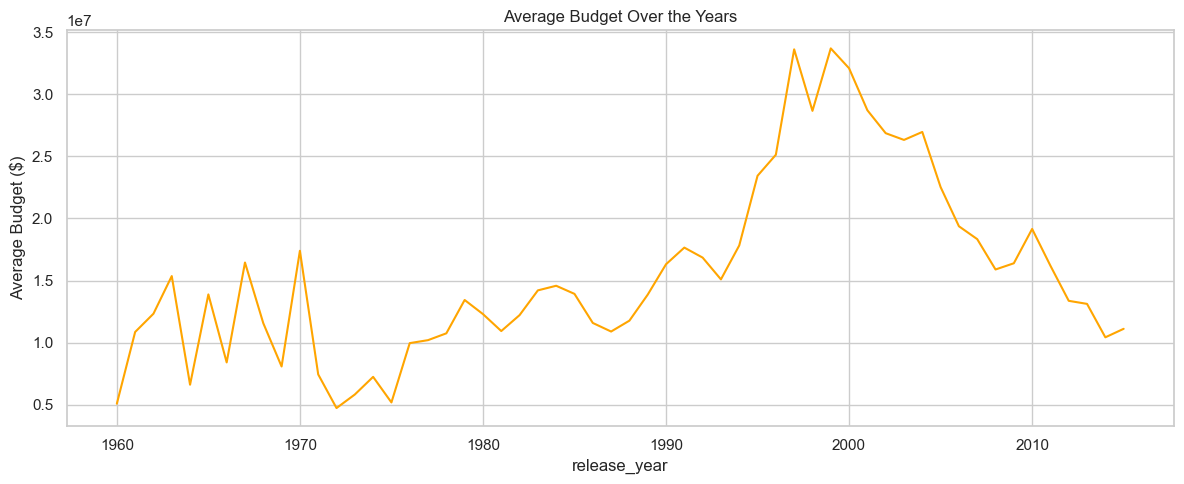

In [31]:
(df.groupby('release_year')['budget_adj']
 .mean()
 .plot(figsize=(12, 5), color='orange', title='Average Budget Over the Years'))
plt.ylabel('Average Budget ($)')
plt.tight_layout()
plt.show()

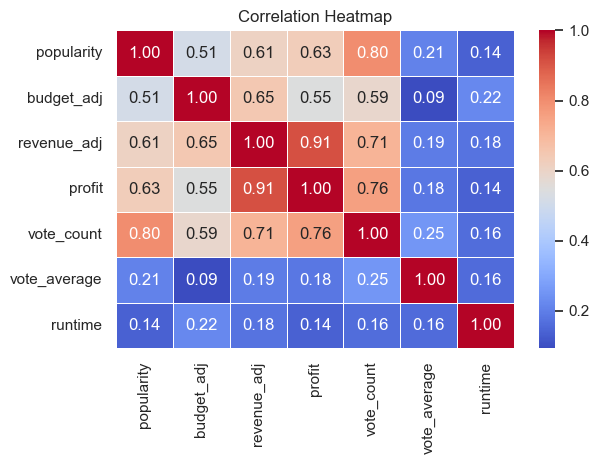

In [41]:
num_cols = ['popularity', 'budget_adj', 'revenue_adj',
            'profit', 'vote_count', 'vote_average', 'runtime']

sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

<a id='conclusions'></a>
## Conclusions

- High-budget movies generate higher revenue but not necessarily higher ROI (ROI=**Budget/Profit**)= **(Revenu-Budget)/Budget**
- Movie profitability has become more volatile in recent years